# scVI / totalVI integration: gex-only, morph-only, joint

Compares three embeddings of the 119 HepG2 drug pseudobulk profiles in
`hepg2_mdata.h5mu`:

- **scVI (gex only)** — transcriptomic profile per drug
- **scVI (morph only)** — Cell Painting morphology profile per drug
- **totalVI (joint)** — both modalities integrated together

In [31]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import mudata as md
import scanpy as sc
import scvi
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.neighbors import NearestNeighbors

scvi.settings.seed = 0
N_LATENT = 20
MAX_EPOCHS = 400
TRAIN_KWARGS = dict(max_epochs=MAX_EPOCHS, train_size=0.9, check_val_every_n_epoch=1)

Seed set to 0


## Load data

`mdata` has drugs as `obs` and each modality's own features as `var`
(`gex`: 41,780 genes; `morph`: 636 Cell Painting features).

columns changed form string to category to avoid scanpy plotting errors

In [32]:
mdata = md.read_h5mu("data/hepg2_mdata.h5mu")
gex = mdata["gex"]
morph = mdata["morph"]

for col in mdata.obs.columns:
    if str(mdata.obs[col].dtype) == "string":
        mdata.obs[col] = mdata.obs[col].astype(str).astype("category")

mdata

MuData object with n_obs × n_vars = 119 × 42416
  obs:	'drug', 'cell_line_id', 'n_cells', 'moa-fine', 'canonical_smiles', 'pubchem_cid'
  2 modalities
    morph:	119 × 636
      obs:	'drug', 'cell_line_id', 'n_cells', 'moa-fine', 'canonical_smiles', 'pubchem_cid'
      layers:	None
    gex:	119 × 41780
      obs:	'drug', 'cell_line_id', 'n_cells', 'moa-fine', 'canonical_smiles', 'pubchem_cid'
      layers:	'log_counts', 'raw_counts', None

Fixed `moa-fine` -> color mapping (`data/mixOmics/moa_fine_colors.csv`), so
every `moa-fine` plot below (and in `wl_diablo_comparison.ipynb`, which loads
the same CSV) uses the same colour per MOA class. Setting
`mdata.uns["moa-fine_colors"]` once here means every later
`sc.pl.embedding(..., color="moa-fine")` picks it up automatically.

In [33]:
moa_fine_colors = pd.read_csv("data/mixOmics/moa_fine_colors.csv").set_index("moa_fine")["color"]
mdata.uns["moa-fine_colors"] = moa_fine_colors.loc[mdata.obs["moa-fine"].cat.categories].to_numpy()


## Non-negative morphology layer

The MAD-robustized (using `pancytominer`) morphology features in `morph.X` are z-scored (negative
valued). Two things downstream need non-negative input:

- **totalVI**'s protein arm assumes count-like data (NB-mixture likelihood,
  plus a hard-coded check on its empirical background-prior init).
- **scVI**'s decoder scales its output by a per-observation "library size" it
  computes as `log(row_sum(X))`, even under a Gaussian (`"normal"`)
  likelihood — a negative row sum breaks that `log()`.

To avoid this, I am shifting each *feature* (column) by its own minimum keeps the covariance
structure intact (PCA-equivalent up to this constant offset) while making
everything non-negative, and storing as a separate layer so `morph.X`
itself is untouched.

In [34]:
morph.layers["nonneg"] = (morph.X - morph.X.min(axis=0, keepdims=True)).astype("float32")

## 1) scVI — gex only

### Highly variable gene selection

Subset to the top 5,000 highly variable genes, using scanpy's `seurat_v3`
selection (a variance-stabilizing-transform rank on the mean-variance trend,
the same method underlying Seurat's `vst`). Unlike the `seurat` flavor,
`seurat_v3` is fit directly on raw counts rather than log-normalized data, so
it runs straight off `gex.layers["raw_counts"]` — no throwaway normalized
copy needed. The resulting `highly_variable` flag is written onto `gex.var`,
and `gex_hvg` is the subset used for scVI training below (and later reused
for totalVI's RNA arm, in place of the full gene set).

In [35]:
sc.pp.highly_variable_genes(gex, flavor="seurat_v3", n_top_genes=5000, layer="raw_counts")

gex_hvg = gex[:, gex.var["highly_variable"]].copy()
print(f"{gex_hvg.n_vars} / {gex.n_vars} genes kept as HVGs")

5000 / 41780 genes kept as HVGs


In [36]:
scvi.model.SCVI.setup_anndata(gex_hvg, layer="raw_counts")

gex_model = scvi.model.SCVI(gex_hvg, n_latent=N_LATENT, n_hidden=64, gene_likelihood="nb")
gex_model.train(**TRAIN_KWARGS)

mdata.obsm["X_scvi_gex"] = gex_model.get_latent_representation()
mdata.obsm["X_scvi_gex"].shape

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


(119, 20)

## 2) scVI — morph only

Same architecture family as the gex model, but with `gene_likelihood="normal"`
(continuous features, not counts) on the non-negative layer.

In [37]:
scvi.model.SCVI.setup_anndata(morph, layer="nonneg")

morph_model = scvi.model.SCVI(morph, n_latent=N_LATENT, n_hidden=64, gene_likelihood="normal")
morph_model.train(**TRAIN_KWARGS)

mdata.obsm["X_scvi_morph"] = morph_model.get_latent_representation()
mdata.obsm["X_scvi_morph"].shape

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


(119, 20)

## 3) totalVI — joint gex + morph

totalVI needs shared *observations*. Normally used for protein+GEX, we're changing protein modality to morphology.
`early_stopping` and `reduce_lr_on_plateau` default to `True` for
totalVI and both watch `elbo_validation`, which is noisy with only ~12
held-out drugs — turned off so a single bad validation batch can't cut
training short.

RNA input is swapped to the same `gex_hvg` (5,000 genes) used for the
gex-only scVI model above, rather than all 41,780 genes, so the three
embeddings are trained on comparable inputs.

In [38]:
mdata.mod["gex"] = gex_hvg  # use the same 5,000 HVGs as the gex-only scVI model, not all genes
mdata.update()

scvi.model.TOTALVI.setup_mudata(
    mdata,
    rna_layer="raw_counts",
    protein_layer="nonneg",
    modalities={"rna_layer": "gex", "protein_layer": "morph"},
)

totalvi_model = scvi.model.TOTALVI(mdata, n_latent=N_LATENT, empirical_protein_background_prior=False)
totalvi_model.train(**TRAIN_KWARGS, early_stopping=False, reduce_lr_on_plateau=False, batch_size=128)

mdata.obsm["X_totalvi_joint"] = totalvi_model.get_latent_representation()
mdata.obsm["X_totalvi_joint"].shape

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


(119, 20)

In [39]:
# sanity check: none of the three latents came out with NaNs
for name, model in [("gex", gex_model), ("morph", morph_model), ("joint", totalvi_model)]:
    lat = model.get_latent_representation()
    assert not np.isnan(lat).any(), f"{name} embedding contains NaNs"
print("all three embeddings are NaN-free")

all three embeddings are NaN-free


## UMAP

Compare the integration quality to cluster MoA together

In [40]:
embedding_keys = {
    "scVI (gex only)": "X_scvi_gex",
    "scVI (morph only)": "X_scvi_morph",
    "totalVI (joint)": "X_totalvi_joint",
}
n_methods = len(embedding_keys)

for key in embedding_keys.values():
    sc.pp.neighbors(mdata, use_rep=key, metric="cosine", key_added=key)
    sc.tl.umap(mdata, neighbors_key=key, key_added=f"{key}_umap")

### Embeddings

Export the embeddings for each method for benchmarking

In [42]:
for emb in ["X_scvi_gex", "X_scvi_morph", "X_totalvi_joint"]:
    embedding_df = pd.DataFrame(
        mdata.obsm[emb],
        index=mdata.obs["drug"].astype(str),
        columns=[f"{emb}_{i + 1}" for i in range(mdata.obsm[emb].shape[1])],
    )
    embedding_df.index.name = "drug"
    embedding_df.to_csv(f"data/scvi/{emb}.csv")

## Compare embeddings by `drug` and `moa-fine`

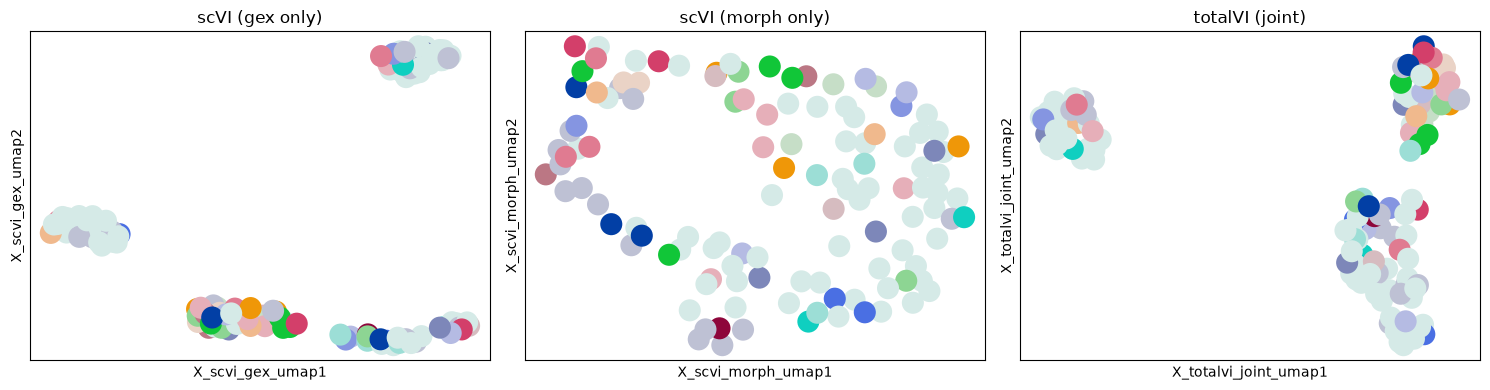

In [41]:
fig, axes = plt.subplots(1, n_methods, figsize=(5 * n_methods, 4), squeeze=False)

for ax, (method_name, key) in zip(axes.ravel(), embedding_keys.items()):
    sc.pl.embedding(
        mdata,
        basis=f"{key}_umap",
        color="moa-fine",
        ax=ax,
        show=False,
        title=method_name,
        legend_loc=None,
        legend_fontsize=8,
    )

fig.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.savefig("figures/umap_comparison_scvi.png", dpi=300)
plt.show()


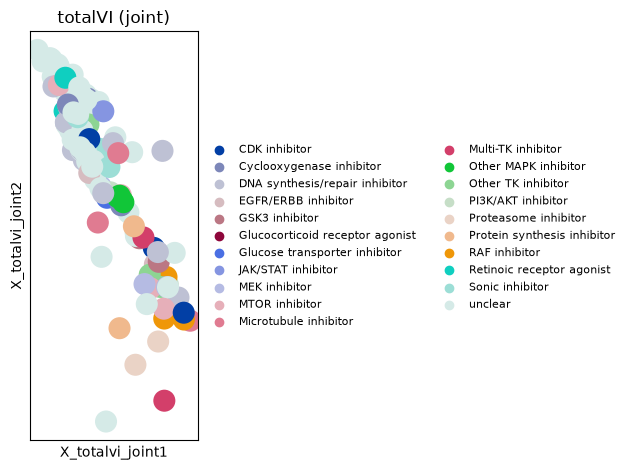

In [11]:
sc.pl.embedding(
    mdata,
    basis="X_totalvi_joint",
    color="moa-fine",
    show=False,
    title=method_name,
    legend_loc="right margin",
    legend_fontsize=8,
)
plt.tight_layout()
plt.savefig("figures/umap_totalVI.png", dpi=300)

## Integration metrics: how well does each embedding recapitulate drug structure?

There's one row per drug (no replicates in this pseudobulked object), so
per-drug reproducibility can't be measured here — instead these metrics ask
*"do embeddings place drugs with a shared, known mechanism of action (MOA)
near each other?"*, using `moa-fine` as the reference grouping. 55/119 drugs
are labeled `"unclear"` (not a real mechanism), so those are excluded from
all label-based metrics below; 64 drugs across 20 MOA categories remain,
mostly with only 2–4 members each — small enough that these numbers are
indicative, not definitive.

- **Silhouette score** (`moa-fine` labels, embedding coordinates): how
  well-separated MOA groups are in the embedding. Ranges -1..1, higher is
  better; expect small/negative values here given tiny group sizes.
- **kNN purity (k=5)**: for each drug, the fraction of its 5 nearest
  neighbors *in the embedding* sharing its MOA label.
- **Enrichment over chance**: kNN purity divided by the purity expected if
  neighbors were random, correcting for the fact that a MOA group of size 2
  can never exceed 1/5 purity at k=5 — an enrichment > 1 means the embedding
  is doing better than chance.
- **ARI / NMI** (K-means, k = number of MOA categories, vs. true `moa-fine`
  labels): a coarser, cluster-level view of the same question.

In [12]:
known = mdata.obs["moa-fine"] != "unclear"
labels_all = mdata.obs["moa-fine"].astype(str).to_numpy(dtype=object)
print(f"{known.sum()} / {mdata.n_obs} drugs have a known moa-fine label")


def knn_purity(X, labels, k=5):
    """Fraction of each point's k nearest neighbors sharing its label."""
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X)
    _, idx = nn.kneighbors(X)
    idx = idx[:, 1:]  # drop self
    return (labels[idx] == labels[:, None]).mean(axis=1)


rows = []
for name, key in embedding_keys.items():
    Xk = mdata.obsm[key][known.values]
    lk = labels_all[known.values]

    silhouette = silhouette_score(Xk, lk, metric="euclidean")

    purity_k5 = knn_purity(Xk, lk, k=5).mean()
    group_size = pd.Series(lk).map(pd.Series(lk).value_counts()).to_numpy()
    chance_k5 = ((group_size - 1) / (len(lk) - 1)).mean()

    kmeans = KMeans(n_clusters=pd.Series(lk).nunique(), n_init=10, random_state=0).fit(Xk)
    ari = adjusted_rand_score(lk, kmeans.labels_)
    nmi = normalized_mutual_info_score(lk, kmeans.labels_)

    rows.append(dict(
        embedding=name,
        silhouette_moa=silhouette,
        knn_purity_k5=purity_k5,
        chance_k5=chance_k5,
        enrichment_k5=purity_k5 / chance_k5,
        ari_kmeans=ari,
        nmi_kmeans=nmi,
    ))

metrics_df = pd.DataFrame(rows).set_index("embedding").round(3)
metrics_df.to_csv("figures/scvi_metrics.csv")
metrics_df

64 / 119 drugs have a known moa-fine label


,silhouette_moa,knn_purity_k5,chance_k5,enrichment_k5,ari_kmeans,nmi_kmeans
embedding,,,,,,
scVI (gex only),-0.460,0.122,0.069,1.768,0.055,0.574
scVI (morph only),-0.327,0.156,0.069,2.266,0.080,0.618
totalVI (joint),-0.411,0.159,0.069,2.312,0.124,0.610


Read the table as: **higher is better** on every column. If `totalVI
(joint)` beats both single-modality scVI rows on `enrichment_k5` (and/or
`ari_kmeans` / `nmi_kmeans`), that's evidence the joint model is picking up
cross-modal structure that neither modality captures alone; if it lands
between the two single-modality rows instead, the joint embedding may just
be dominated by whichever modality has the stronger MOA signal on its own.